In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


%matplotlib notebook

### розвідувальний аналіз даних та передобробка

In [2]:
df_train = pd.read_csv('data/train.csv')
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df_test = pd.read_csv('data/test.csv')
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
df_train = df_train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis='columns') # видаляю не потрібні мені колонки
df_test = df_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis='columns')

In [6]:
df_train['Age'] = df_train.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median())) # заповнив NaN в 'Age' з допомогою групової медіани по 'Sex', 'Pclass'
df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True) # заповнення Embarked — найчастіше значення
df_test['Age'] = df_test.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df_test['Fare'].fillna(df_test['Fare'].median(), inplace=True)
df_test['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True)

In [7]:
df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,21.5,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [8]:
df_train = pd.get_dummies(df_train, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True) # Кодування категорій
df_test = pd.get_dummies(df_test, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

In [9]:
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Масштабування — лише для моделей, що потребують
X_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(df_test)

### треную

In [11]:
!pip install xgboost

You should consider upgrading via the 'pip install --upgrade pip' command.


In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Словник моделей
models = {
    'RandomForest': RandomForestClassifier(random_state=0),
    'SVC_poly': SVC(kernel='poly', degree=3, C=1, probability=True),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=0)
}

# Крос-валідація
for name, model in models.items():
    if name in ['SVC_poly', 'MLP']:
        scores = cross_val_score(model, X_train_scaled, y, cv=5)
    else:
        scores = cross_val_score(model, X, y, cv=5)
    
    print(f"{name} cross-val accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

/usr/local/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)
/usr/local/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)
/usr/local/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)
/usr/local/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)
/usr/local/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The de

RandomForest cross-val accuracy: 0.7991 ± 0.0143
SVC_poly cross-val accuracy: 0.8216 ± 0.0288


/usr/local/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


XGBoost cross-val accuracy: 0.8194 ± 0.0306


/usr/local/lib/python3.6/site-packages/sklearn/neural_network/multilayer_perceptron.py:566: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


MLP cross-val accuracy: 0.8171 ± 0.0189


In [13]:
# ==== остаточний прогноз і збереження у файли ====
test_passenger_ids = pd.read_csv('data/test.csv')['PassengerId']

for name, model in models.items():
    if name in ['SVC_poly', 'MLP']:
        model.fit(X_train_scaled, y)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X, y)
        predictions = model.predict(df_test)

    submission = pd.DataFrame({
        'PassengerId': test_passenger_ids,
        'Survived': predictions.astype(int)
    })

    submission.to_csv(f'submission_{name}.csv', index=False)

/usr/local/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


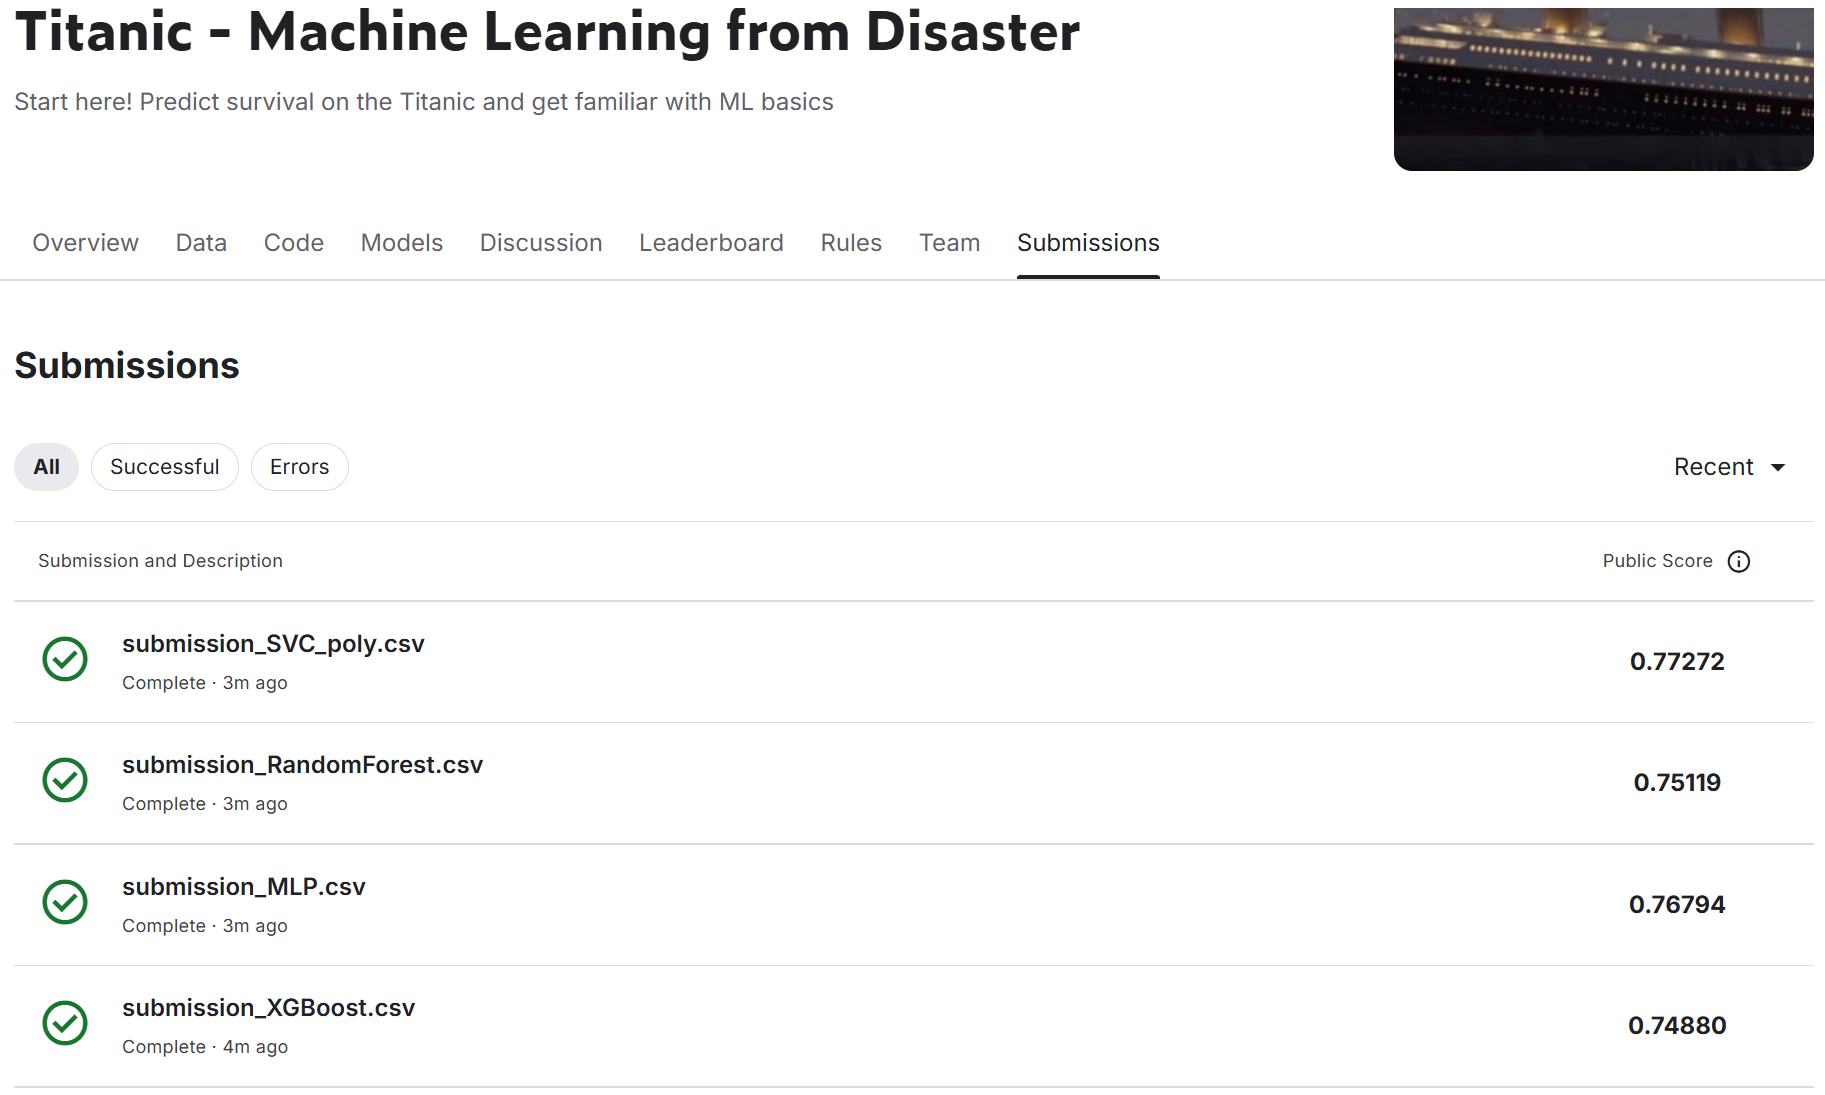

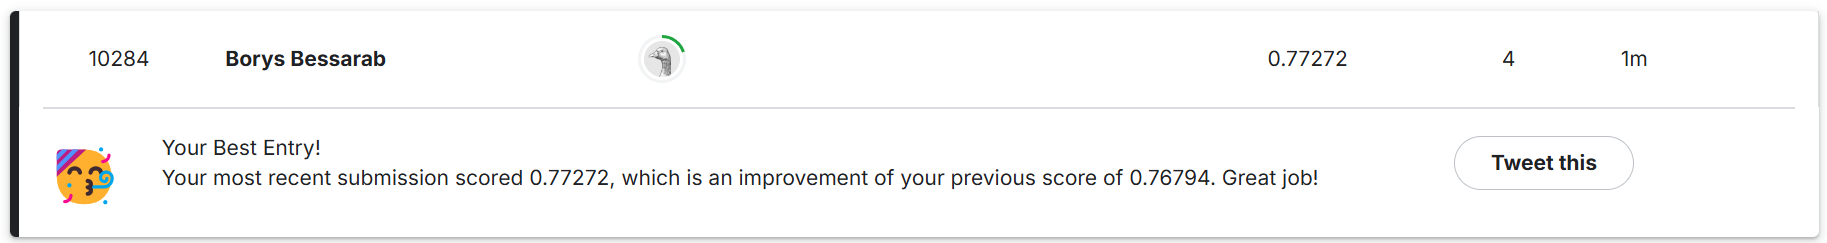